In [3]:
# 步骤1：环境准备
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

In [18]:
# 步骤2：参数设置
symbol = 'AAPL'        # 股票代码
period = '1y'          # 时间周期
atr_period = 14        # ATR周期
ma_period = 20         # MA周期
boll_k = 2             # k系数 - 用来确定放大布林带的倍数

In [5]:
# 步骤3：获取股票数据
ticker = yf.Ticker(symbol)
df = ticker.history(period=period)
print(f"✅ 数据获取完成，共 {len(df)} 个交易日")

✅ 数据获取完成，共 250 个交易日


In [6]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-10-07 00:00:00-04:00,223.460005,224.644495,220.304692,220.663025,39505400,0.0,0.0
2024-10-08 00:00:00-04:00,223.260945,224.933155,222.215806,224.724136,31855700,0.0,0.0
2024-10-09 00:00:00-04:00,224.186622,228.685688,223.788482,228.476654,33591100,0.0,0.0
2024-10-10 00:00:00-04:00,226.724816,228.436849,226.117641,227.978973,28183500,0.0,0.0
2024-10-11 00:00:00-04:00,228.237789,228.347280,226.286862,226.495895,31759200,0.0,0.0


In [15]:
# pd.concat?
pd.concat([tr1,tr2,tr3],axis=1),pd.concat([tr1,tr2,tr3],axis=1).max(axis=1)

(                                  0         1         2
 Date                                                   
 2024-10-07 00:00:00-04:00  4.339803       NaN       NaN
 2024-10-08 00:00:00-04:00  2.717349  0.079641  4.419444
 2024-10-09 00:00:00-04:00  4.897206  3.543499  6.260848
 2024-10-10 00:00:00-04:00  2.319208  0.706715  4.190492
 2024-10-11 00:00:00-04:00  2.060418  1.940954  0.378254
 ...                             ...       ...       ...
 2025-09-30 00:00:00-04:00  2.809998  0.369995  1.620010
 2025-10-01 00:00:00-04:00  3.860016  0.470001  2.339996
 2025-10-02 00:00:00-04:00  4.029999  1.660004  2.200012
 2025-10-03 00:00:00-04:00  5.289993  0.160004  3.869995
 2025-10-06 00:00:00-04:00  4.020004  2.549988  2.740005
 
 [250 rows x 3 columns],
 Date
 2024-10-07 00:00:00-04:00    4.339803
 2024-10-08 00:00:00-04:00    4.419444
 2024-10-09 00:00:00-04:00    6.260848
 2024-10-10 00:00:00-04:00    4.190492
 2024-10-11 00:00:00-04:00    2.060418
                               

In [17]:
# 步骤4：计算 ATR -> 计算单日的最大波幅 = max（1,2,3）-> n日的单日波幅的移动平均线 -> ATR(14)
tr1 = df['High']-df['Low']
tr2 = (df['Close'] - df['High'].shift(1)).abs()
tr3 = (df['Close'] - df['Low'].shift(1)).abs()

df['MTR'] = pd.concat([tr1,tr2,tr3],axis=1).max(axis=1)
df['ATR'] = df['MTR'].rolling(window=atr_period).mean()

df[['Close','MTR','ATR']]

,Close,MTR,ATR
Date,,,
2024-10-07 00:00:00-04:00,220.663025,4.339803,NaN
2024-10-08 00:00:00-04:00,224.724136,4.419444,NaN
2024-10-09 00:00:00-04:00,228.476654,6.260848,NaN
2024-10-10 00:00:00-04:00,227.978973,4.190492,NaN
2024-10-11 00:00:00-04:00,226.495895,2.060418,NaN
...,...,...,...
2025-09-30 00:00:00-04:00,254.630005,2.809998,5.927858
2025-10-01 00:00:00-04:00,255.449997,3.860016,5.912144
2025-10-02 00:00:00-04:00,257.130005,4.029999,5.670000


In [19]:
# 步骤5：计算 BOLL -> 中轨：n日的移动均线，上轨：中轨 + k * close的标准差，下轨：中轨 - k * close的标准差，k=2，n=20
df['MA'] = df['Close'].rolling(window=ma_period).mean()
df['STD'] = df['Close'].rolling(window=ma_period).std()

df['BOLL_UP'] = df['MA'] + boll_k * df['STD']
df['BOLL_DN'] = df['MA'] - boll_k * df['STD']

# 简单信号逻辑，收盘价 > 上轨：超买（卖出信号：-1），收盘价 < 下轨：超卖（买入信号：1）
df['Signal'] = 0
df.loc[df['Close'] > df['BOLL_UP'],'Signal'] = -1
df.loc[df['Close'] < df['BOLL_DN'],'Signal'] = 1

df[['BOLL_UP','MA','BOLL_DN','Signal']]

,BOLL_UP,MA,BOLL_DN,Signal
Date,,,,
2024-10-07 00:00:00-04:00,NaN,NaN,NaN,0
2024-10-08 00:00:00-04:00,NaN,NaN,NaN,0
2024-10-09 00:00:00-04:00,NaN,NaN,NaN,0
2024-10-10 00:00:00-04:00,NaN,NaN,NaN,0
2024-10-11 00:00:00-04:00,NaN,NaN,NaN,0
...,...,...,...,...
2025-09-30 00:00:00-04:00,262.411781,243.124500,223.837218,0
2025-10-01 00:00:00-04:00,263.882946,243.973499,224.064053,0
2025-10-02 00:00:00-04:00,265.479700,244.841000,224.202299,0


In [20]:
# 步骤6：统计指标
print("📊 ATR 统计")
print("=" * 50)

atr_mean = df['ATR'].mean()
atr_std = df['ATR'].std()
atr_latest = df['ATR'].iloc[-1]

print(f"ATR均值：{atr_mean:.4f} \n标准差：{atr_std:.4f} \n当前值：{atr_latest:.4f}")

print("\n📈 BOLL 统计")
print("=" * 50)

signal_counts = df['Signal'].value_counts().rename({1: 'Buy(下轨突破)', -1: 'Sell(上轨突破)', 0: '无信号'})
signal_ratio = (signal_counts / len(df) * 100).round(2)

print("信号次数：",signal_counts)
print("\n信号占比（%）：",signal_ratio)

📊 ATR 统计
ATR均值：6.2564 
标准差：2.3618 
当前值：5.4364

📈 BOLL 统计
信号次数： Signal
无信号           217
Sell(上轨突破)     19
Buy(下轨突破)      14
Name: count, dtype: int64

信号占比（%）： Signal
无信号           86.8
Sell(上轨突破)     7.6
Buy(下轨突破)      5.6
Name: count, dtype: float64


In [21]:
# 步骤7：分析当前状态
print("\n📉 当前趋势判断")
print("=" * 50)

# 判断ATR波动区间
if atr_latest > atr_mean + atr_std:
    atr_status = "高波动（市场较活跃）"
elif atr_latest < atr_mean - atr_std:
    atr_status = "低波动（市场平稳）"
else:
    atr_status = "中等波动"
    
# 判断BOLL趋势方向
latest_close = df['Close'].iloc[-1]
latest_ma = df['MA'].iloc[-1]

if latest_close > df['BOLL_UP'].iloc[-1]:
    boll_signal = "突破上轨 → 超买（潜在卖出区）"
elif latest_close < df['BOLL_DN'].iloc[-1]:
    boll_signal = "跌破下轨 → 超卖（潜在买入区）"
else:
    boll_signal = "位于布林带内部 → 无明显信号"

# 判断趋势（基于中轨）
if latest_close > latest_ma:
    trend = "价格位于中轨上方 → 上升趋势"
elif latest_close < latest_ma:
    trend = "价格位于中轨下方 → 下降趋势"
else:
    trend = "价格接近中轨 → 震荡趋势"

print(f"布林带信号：{boll_signal}")
print(f"总体趋势：{trend}")
print(f"波动状态：{atr_status}")


📉 当前趋势判断
布林带信号：位于布林带内部 → 无明显信号
总体趋势：价格位于中轨上方 → 上升趋势
波动状态：中等波动


(array([20028.16666667, 20089.20833333, 20148.20833333, 20209.16666667,
        20270.16666667, 20332.16666667]),
 [Text(20028.166666666668, 0, '2024-11'),
  Text(20089.208333333332, 0, '2025-01'),
  Text(20148.208333333332, 0, '2025-03'),
  Text(20209.166666666668, 0, '2025-05'),
  Text(20270.166666666668, 0, '2025-07'),
  Text(20332.166666666668, 0, '2025-09')])

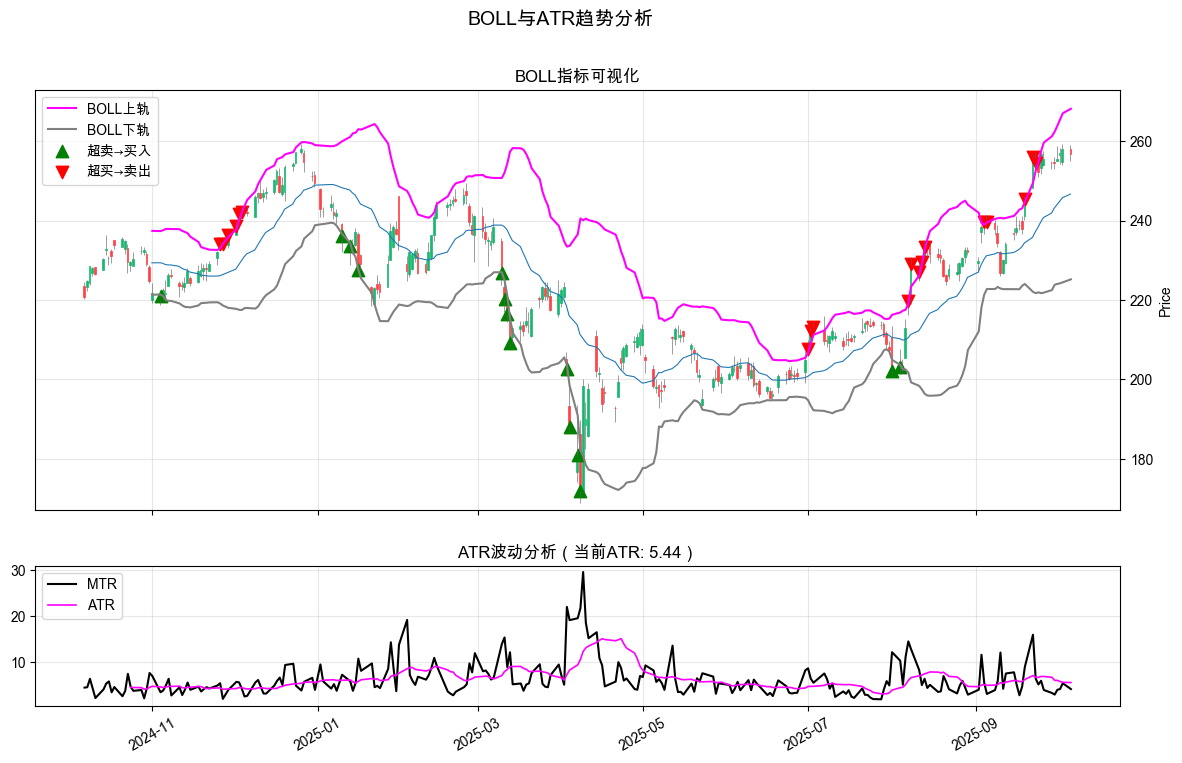

In [23]:
# 步骤8：绘制图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f"BOLL与ATR趋势分析", fontsize=14, fontweight='bold')

# === 主图：蜡烛 + BOLL ===
mpf.plot(
    df,
    type='candle',
    ax=ax1,
    axtitle='BOLL指标可视化',
    style='yahoo',
    mav=(ma_period,),
    show_nontrading=True
)

ax1.plot(df.index, df['BOLL_UP'], color='magenta', label='BOLL上轨')
ax1.plot(df.index, df['BOLL_DN'], color='gray', label='BOLL下轨')

# 信号标注
buy = df[df['Signal'] == 1]
sell = df[df['Signal'] == -1]
ax1.scatter(buy.index, buy['Close'], marker='^', color='green', s=80, label='超卖→买入')
ax1.scatter(sell.index, sell['Close'], marker='v', color='red', s=80, label='超买→卖出')

ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# === 副图：ATR ===
ax2.plot(df.index, df['MTR'], color='black', label='MTR')
ax2.plot(df.index, df['ATR'], color='magenta', label='ATR', linewidth=1.2)
ax2.set_title(f"ATR波动分析（当前ATR: {df['ATR'].iloc[-1]:.2f}）", fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# 优化x轴
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)